# PCT Evaluation of lean models

Load and test trained models, and show various evaluation metrics.

Note: Does no longer use original PCT data.

## Prep

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Paths, folders
import os

REPO_PATH = '/content/pointcloud-bench'
DATASET_PATH = '/content/drive/MyDrive/_Temp/cs7643-final-proj/pointcloud-bench/datasets'
RESULTS_PATH = '/content/drive/MyDrive/_Temp/cs7643-final-proj/pointcloud-bench/results'
CHECKPOINTS_PATH = '/content/drive/MyDrive/_Temp/cs7643-final-proj/pointcloud-bench/checkpoints'

os.makedirs(RESULTS_PATH, exist_ok=True)

In [3]:
# Get repo
!git clone --recursive --branch lean-model https://github.com/DavidClaszen/pointcloud-bench {REPO_PATH}
%cd {REPO_PATH}
%pip install -r envs/pct/requirements.txt

Cloning into '/content/pointcloud-bench'...
remote: Enumerating objects: 665, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 665 (delta 35), reused 34 (delta 34), pack-reused 605 (from 1)
Receiving objects: 100% (665/665), 62.90 MiB | 41.80 MiB/s, done.
Resolving deltas: 100% (304/304), done.
Submodule 'repos/PAPNet' (https://github.com/DavidClaszen/PAPNet.git) registered for path 'repos/PAPNet'
Submodule 'repos/Point-Transformers' (https://github.com/DavidClaszen/Point-Transformers.git) registered for path 'repos/Point-Transformers'
Cloning into '/content/pointcloud-bench/repos/PAPNet'...
remote: Enumerating objects: 145, done.        
remote: Counting objects: 100% (145/145), done.        
remote: Compressing objects: 100% (117/117), done.        
remote: Total 145 (delta 63), reused 88 (delta 27), pack-reused 0 (from 0)        
Receiving objects: 100% (145/145), 9.66 MiB | 13.80 MiB/s, done.
Resolving deltas: 100% (

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix
from hydra import initialize_config_dir, compose
from omegaconf import OmegaConf
from IPython.display import display, HTML
from tqdm import tqdm

In [8]:
# Copy select files from Google Drive to the repo dataset folder
!mkdir /content/downloads
!rsync -avP {DATASET_PATH}/fullmodelnet40.tar.gz /content/downloads
!rsync -avP {DATASET_PATH}/partialmodelnet40.tar.gz /content/downloads
!rsync -avP {DATASET_PATH}/pm40_extreme_partiality.tar.gz /content/downloads

# Extract zip files
!tar -xvzf /content/downloads/fullmodelnet40.tar.gz -C {REPO_PATH}/datasets
!tar -xvzf /content/downloads/partialmodelnet40.tar.gz -C {REPO_PATH}/datasets
!tar -xvzf /content/downloads/pm40_extreme_partiality.tar.gz -C {REPO_PATH}/datasets

mkdir: cannot create directory ‘/content/downloads’: File exists
sending incremental file list
fullmodelnet40.tar.gz
  1,833,210,387 100%   89.65MB/s    0:00:19 (xfr#1, to-chk=0/1)

sent 1,833,658,058 bytes  received 35 bytes  85,286,422.93 bytes/sec
total size is 1,833,210,387  speedup is 1.00
sending incremental file list
partialmodelnet40.tar.gz
  2,162,130,396 100%   90.55MB/s    0:00:22 (xfr#1, to-chk=0/1)

sent 2,162,658,366 bytes  received 35 bytes  92,028,017.06 bytes/sec
total size is 2,162,130,396  speedup is 1.00
sending incremental file list
pm40_extreme_partiality.tar.gz
  8,334,013,260 100%   70.08MB/s    0:01:53 (xfr#1, to-chk=0/1)

sent 8,336,048,044 bytes  received 35 bytes  72,173,576.44 bytes/sec
total size is 8,334,013,260  speedup is 1.00
fullmodelnet40/
fullmodelnet40/test_filenames.txt
fullmodelnet40/test_gt_rot.npy
fullmodelnet40/test_gt_tra.npy
fullmodelnet40/test_labels.npy
fullmodelnet40/test_points.npy
fullmodelnet40/train_filenames.txt
fullmodelnet40/train_

## Get Predictions

Upload checkpoints, get test results, visualize and analyze.

You can get the trained model checkpoints from [this folder](https://drive.google.com/drive/folders/1Wo8HHyUl0lcGMnldIeJqdC2i4IsdTFcX?usp=drive_link).

Copy those files into your own Google Drive and, if necessary, change the first path in the code below. Contents:

- Evaluated in this notebook:
- pct-minimal_p50           : Lean PCT model with minimal settings.
- pct-set_decoder_lbrd1_p50 : Lean PCT model with decoder using 1 layer of linear, bn, relu, dropout layer
- pct-set_sa_ch_64_p50      : Lean PCT model with stacked attention using 64 channels
- pct-set_sa_ch_128_p50     : Lean PCT model with stacked attention using 128 channels
- pct-set_sa_layer1_p50     : Lean PCT model with 1 stacked attention layer
- pct-set_sa_stacks1_p50    : Lean PCT model with 1 stacked attention layer stack
- pct-set_sa_stacks2_p50    : Lean PCT model with 2 stacked attention layer stacks
- pct-set_sa_stacks3_p50    : Lean PCT model with 3 stacked attention layer stacks


In [134]:
!rsync -avP {CHECKPOINTS_PATH}/pct*.pth {REPO_PATH}/checkpoints

sending incremental file list
pct_pct.pth
     34,642,219 100%   28.11MB/s    0:00:01 (xfr#1, to-chk=3/24)
pct_pct_p50.pth
     34,641,609 100%   10.66MB/s    0:00:03 (xfr#2, to-chk=2/24)
pct_pfull.pth
     34,642,686 100%   16.37MB/s    0:00:02 (xfr#3, to-chk=1/24)
pct_pfull_p50.pth
     34,642,379 100%   11.67MB/s    0:00:02 (xfr#4, to-chk=0/24)

sent 138,603,433 bytes  received 92 bytes  16,306,297.06 bytes/sec
total size is 692,395,352  speedup is 5.00


In [11]:
%cd {REPO_PATH}/repos/Point-Transformers/
!python test_cls.py --help

/content/pointcloud-bench/repos/Point-Transformers
test_cls is powered by Hydra.

== Configuration groups ==
Compose your configuration from those groups (group=option)

model: Hengshuang, Lean, Menghao, Nico, Patch, lean_minimal, lean_set_decoder_lbrd1, lean_set_sa_ch_128, lean_set_sa_ch_64, lean_set_sa_layer1, lean_set_sa_stacks1, lean_set_sa_stacks2, lean_set_sa_stacks3


== Config ==
Override anything in the config (foo.bar=value)

model:
  name: Menghao
batch_size: 16
epoch: 200
learning_rate: 0.001
gpu: 0
num_point: 1024
optimizer: Adam
weight_decay: 0.0001
normal: true
use_papnet_loader: false
workers: 2
step_size: 50
data_path: ../../datasets/modelnet40_normal_resampled/
checkpoint_path: best_model.pth
partiality: ''
occlusion: false
occlusion_min: 0.1
occlusion_max: 0.9


Powered by Hydra (https://hydra.cc)
Use --hydra-help to view Hydra specific help




## Configs

In [15]:
# Prepare configs
models = ['Patch',
          'lean_minimal',
          'lean_set_decoder_lbrd1',
          'lean_set_sa_ch_128',
          'lean_set_sa_ch_64',
          'lean_set_sa_layer1',
          'lean_set_sa_stacks1',
          'lean_set_sa_stacks2',
          'lean_set_sa_stacks3']
checkpoints = ['pct-p_p50',
               'pct-minimal_p50',
               'pct-set_decoder_lbrd1_p50',
               'pct-set_sa_ch_128_p50',
               'pct-set_sa_ch_64_p50',
               'pct-set_sa_layer1_p50',
               'pct-set_sa_stacks1_p50',
               'pct-set_sa_stacks2_p50',
               'pct-set_sa_stacks3_p50']
test_sets = ["fullmodelnet40", "partialmodelnet40",] + ["pm40_partiality_level"] * 4
partialities = ["", "", "_10", "_20", "_30", "_40"]

# Inference
Load this code once if you still don't have the pickled results file

In [16]:
# Function for inference

from test_cls import get_predictions

config_dir = f'{REPO_PATH}/repos/Point-Transformers/config'

def test_pct(
    data_folder: str = 'partialmodelnet40',
    checkpoint: str = 'pct_p50',
    config_dir: str = config_dir,
    partiality: str = '',
    model: str = ''
) -> tuple[np.array, np.array]:
    """Gets predictions from pretrained PCT model.

    Args:
        data_folder (str, optional): Dataset folder to test on.
            Defaults to 'partialmodelnet40'.
        checkpoint (str, optional): Checkpoint name; omit extension.
            Defaults to 'pct_p50'.
        config_dir (str, optional): Where the model configs reside.
            Only necessary to run, but not used. Defaults to config_dir.
        partiality (str, optional): Used only for extreme partiality
            datasets with non-standard filenames. Use '_10', '_20',
            '_30', '_40'.

    Returns:
        tuple(np.array, np.array): Tuple of predictions and base truths
    """
    if data_folder in ['partialmodelnet40', 'pm40_partiality_level', 'fullmodelnet40']:
        papnet_loader = 'true'
    else: papnet_loader = 'false'

    with initialize_config_dir(config_dir=config_dir, version_base='1.2'):
        cfg = compose(
            config_name='cls',
            overrides=[
                f'data_path=../../datasets/{data_folder}/',
                f'checkpoint_path=../../checkpoints/{checkpoint}.pth',
                f'model={model}',
                f'use_papnet_loader={papnet_loader}',
                f'partiality={partiality}'
            ],
        )
    OmegaConf.set_struct(cfg, False)
    y_true, y_pred = get_predictions(cfg)
    accuracy = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {accuracy:.4f} for dataset {data_folder} and model {checkpoint}')
    return (y_true, y_pred)

In [17]:
import pickle
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm

results = {}

for i in tqdm(range(len(models)), desc=f"Running across models..."):
  if models[i] not in results:
    results[models[i]] = {}
  for j in tqdm(range(len(test_sets)), leave=False, desc=f"Running across test sets..."):
    y_true, y_pred = test_pct(
      data_folder=test_sets[j],
      checkpoint=checkpoints[i],
      model=models[i],
      partiality=partialities[j]
    )
    # Compute instance accuracy, per-class accuracy, and mean-class accuracy
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal().astype(float) / cm.sum(axis=1)
    if test_sets[j] not in results[models[i]]:
      results[models[i]][test_sets[j]] = {}
    results[models[i]][test_sets[j]]["inst_acc"] = accuracy_score(y_true, y_pred)
    results[models[i]][test_sets[j]]["per_class_acc"] = per_class_acc
    results[models[i]][test_sets[j]]["mean_class_acc"] = per_class_acc.mean()
    results[models[i]][test_sets[j]]["confusion_matrix"] = cm

# Write the results to a pickle file

predictions_pkl_path = f'{RESULTS_PATH}/predictions_pct-lean'
if not os.path.exists(predictions_pkl_path):
  os.mkdir(predictions_pkl_path)
with open(os.path.join(predictions_pkl_path, "results.pkl"), 'wb') as file:
    pickle.dump(results, file)

Running across test sets...:   0%|          | 0/6 [00:00<?, ?it/s]

The size of test data is 2468
Total number of parameters: 2876652
Model loaded with 50 epochs



Running across test sets...:  17%|█▋        | 1/6 [00:16<01:20, 16.05s/it]

# iterations (batches): 155
Average inference time per batch: 99.634 ms
Average inference time per sample: 6.257429 ms
Accuracy: 0.1406 for dataset fullmodelnet40 and model pct-p_p50
The size of test data is 2468
Total number of parameters: 2876652
Model loaded with 50 epochs



Running across test sets...:  33%|███▎      | 2/6 [00:32<01:04, 16.02s/it]

...

# iterations (batches): 155
Average inference time per batch: 94.621 ms
Average inference time per sample: 5.942595 ms
Accuracy: 0.2569 for dataset pm40_partiality_level and model pct-set_sa_stacks3_p50
The size of test data is 2468
Total number of parameters: 2055080
Model loaded with 27 epochs



Running across test sets...:  83%|████████▎ | 5/6 [01:15<00:15, 15.14s/it]

# iterations (batches): 155
Average inference time per batch: 93.776 ms
Average inference time per sample: 5.889473 ms
Accuracy: 0.4279 for dataset pm40_partiality_level and model pct-set_sa_stacks3_p50
The size of test data is 2468
Total number of parameters: 2055080
Model loaded with 27 epochs



Running across models...: 100%|██████████| 9/9 [13:45<00:00, 91.74s/it]

# iterations (batches): 155
Average inference time per batch: 94.578 ms
Average inference time per sample: 5.939855 ms
Accuracy: 0.6175 for dataset pm40_partiality_level and model pct-set_sa_stacks3_p50


# Analysis

In [18]:
# Load the json file
#
import json
import numpy as np
import pandas as pd

predictions_pkl_path = f'{RESULTS_PATH}/predictions_pct-lean'
with open(os.path.join(predictions_pkl_path, "results.pkl"), 'rb') as f:
    results = pickle.load(f)

## Instance Accuracy

In [19]:
inst_acc_table = pd.DataFrame.from_dict({
  model: {
    test_set: f"{results[model][test_set]['inst_acc']*100:.2f}"
    for test_set in results[model]
  }
  for model in results
})
inst_acc_table = inst_acc_table.transpose()

In [20]:
inst_acc_table

,fullmodelnet40,partialmodelnet40,pm40_partiality_level
Patch,14.06,82.90,66.53
lean_minimal,8.23,72.16,57.21
lean_set_decoder_lbrd1,13.41,76.90,61.35
lean_set_sa_ch_128,11.47,74.84,58.23
lean_set_sa_ch_64,5.88,70.22,54.90
lean_set_sa_layer1,10.90,76.90,62.44
lean_set_sa_stacks1,10.25,75.69,60.09
lean_set_sa_stacks2,8.75,76.70,61.63
lean_set_sa_stacks3,10.25,76.94,61.75


## Mean Class Accuracy

In [21]:
mean_class_acc_table = pd.DataFrame.from_dict({
  model: {
    test_set: f"{results[model][test_set]['mean_class_acc']*100:.2f}"
    for test_set in results[model]
  }
  for model in results
})
mean_class_acc_table = mean_class_acc_table.transpose()

In [22]:
mean_class_acc_table

,fullmodelnet40,partialmodelnet40,pm40_partiality_level
Patch,14.40,78.72,62.74
lean_minimal,7.68,65.70,52.13
lean_set_decoder_lbrd1,13.08,71.35,55.94
lean_set_sa_ch_128,9.57,69.71,53.06
lean_set_sa_ch_64,6.42,63.88,50.22
lean_set_sa_layer1,10.93,71.16,57.79
lean_set_sa_stacks1,9.43,70.26,54.95
lean_set_sa_stacks2,8.30,71.19,56.85
lean_set_sa_stacks3,9.12,71.78,56.61


# Per Class Accuracies in `testmodelnet40`

In [25]:
per_class_acc_table = pd.DataFrame.from_dict({
  model: results[model]["partialmodelnet40"]["per_class_acc"]
  for model in results
})
per_class_acc_table = per_class_acc_table.transpose()

In [45]:
per_class_acc_table

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
Patch,1.0,0.72,0.93,0.75,0.91,0.97,0.80,0.98,0.98,1.00,...,0.85,0.50,0.75,0.72,0.80,0.95,0.63,0.80,0.25,0.70
lean_minimal,1.0,0.54,0.76,0.45,0.86,0.93,0.80,0.96,0.99,0.90,...,0.80,0.30,0.35,0.75,0.40,0.92,0.43,0.75,0.00,0.55
lean_set_decoder_lbrd1,1.0,0.60,0.84,0.65,0.89,0.92,0.95,0.95,0.96,0.95,...,0.80,0.50,0.70,0.74,0.60,0.96,0.50,0.78,0.00,0.50
lean_set_sa_ch_128,1.0,0.58,0.80,0.75,0.86,0.91,0.85,0.98,0.94,0.95,...,0.80,0.40,0.50,0.73,0.60,0.93,0.52,0.75,0.05,0.55
lean_set_sa_ch_64,1.0,0.38,0.73,0.65,0.84,0.90,0.90,0.98,0.96,0.90,...,0.75,0.25,0.45,0.71,0.45,0.93,0.45,0.69,0.00,0.45
lean_set_sa_layer1,1.0,0.52,0.84,0.65,0.87,0.94,0.90,0.98,0.98,0.95,...,0.81,0.35,0.60,0.79,0.65,0.94,0.53,0.78,0.00,0.55
lean_set_sa_stacks1,1.0,0.58,0.81,0.65,0.87,0.95,0.85,0.97,0.95,1.00,...,0.82,0.35,0.55,0.73,0.65,0.96,0.51,0.79,0.00,0.60
lean_set_sa_stacks2,1.0,0.62,0.85,0.75,0.89,0.94,0.80,0.93,0.99,1.00,...,0.82,0.35,0.60,0.70,0.55,0.96,0.55,0.75,0.00,0.60
lean_set_sa_stacks3,1.0,0.60,0.81,0.65,0.90,0.95,0.95,0.98,0.98,1.00,...,0.83,0.45,0.55,0.77,0.65,0.96,0.53,0.74,0.00,0.70


In [27]:
inst_acc_table.to_latex()

'\\begin{tabular}{llll}\n\\toprule\n & fullmodelnet40 & partialmodelnet40 & pm40_partiality_level \\\\\n\\midrule\nPatch & 14.06 & 82.90 & 66.53 \\\\\nlean_minimal & 8.23 & 72.16 & 57.21 \\\\\nlean_set_decoder_lbrd1 & 13.41 & 76.90 & 61.35 \\\\\nlean_set_sa_ch_128 & 11.47 & 74.84 & 58.23 \\\\\nlean_set_sa_ch_64 & 5.88 & 70.22 & 54.90 \\\\\nlean_set_sa_layer1 & 10.90 & 76.90 & 62.44 \\\\\nlean_set_sa_stacks1 & 10.25 & 75.69 & 60.09 \\\\\nlean_set_sa_stacks2 & 8.75 & 76.70 & 61.63 \\\\\nlean_set_sa_stacks3 & 10.25 & 76.94 & 61.75 \\\\\n\\bottomrule\n\\end{tabular}\n'

## Quick Visualization

In [30]:
# Load class names from dataset
class_names_path = os.path.join(REPO_PATH, 'datasets', 'partialmodelnet40', 'partialmodelnet40_shape_names.txt')
with open(class_names_path, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]
    class_names = {i: name for i, name in enumerate(class_names)}

In [35]:
cm_savepath = os.path.join(RESULTS_PATH, "cm_pct_lean")
if not os.path.exists:
  os.mkdir(cm_savepath)

/tmp/ipython-input-2722710566.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(5, 4), dpi=150)


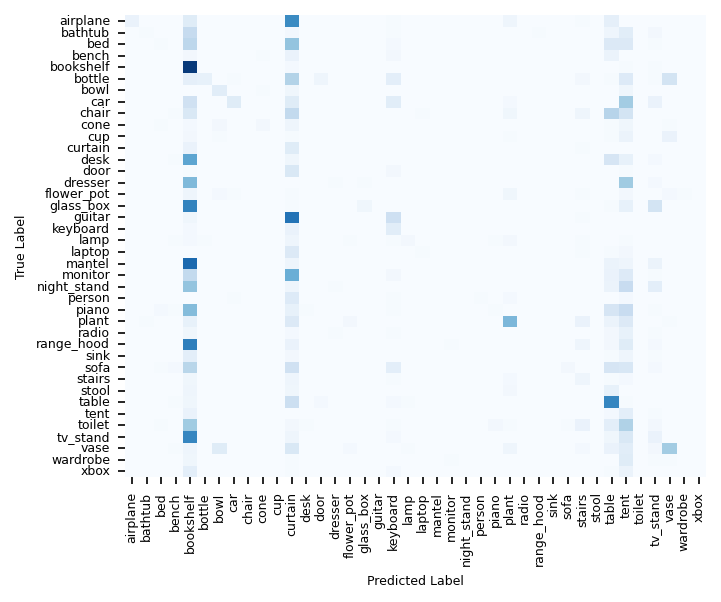

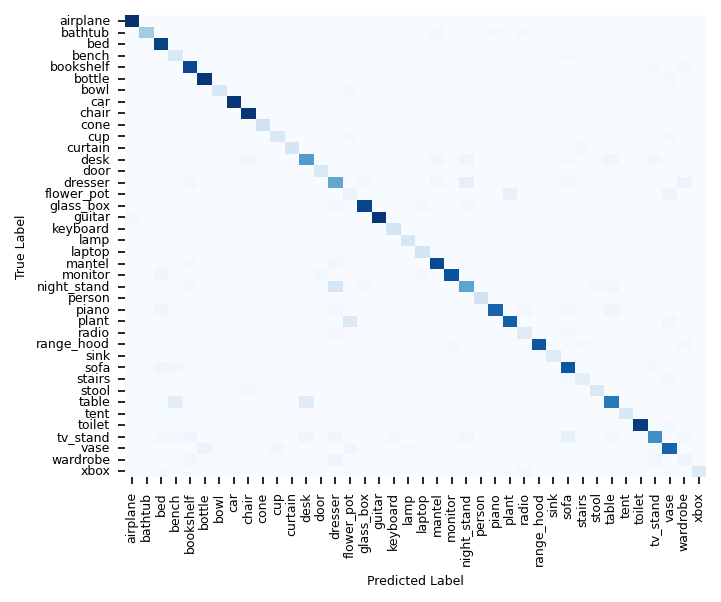

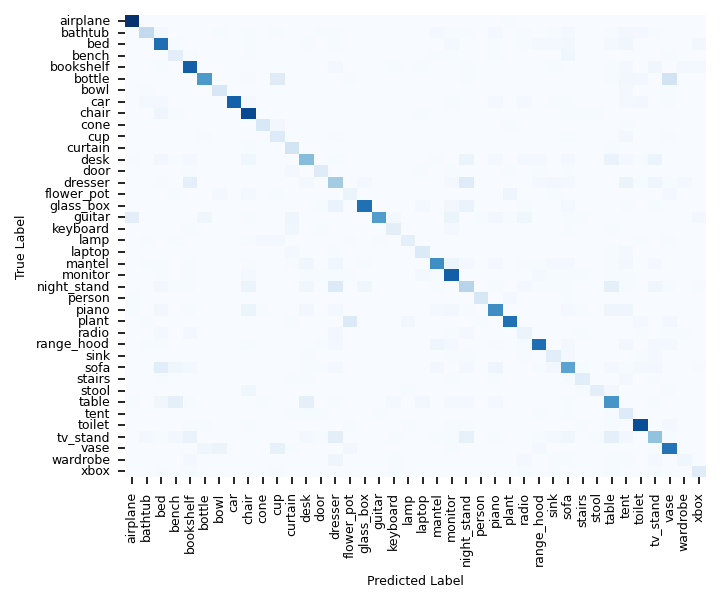

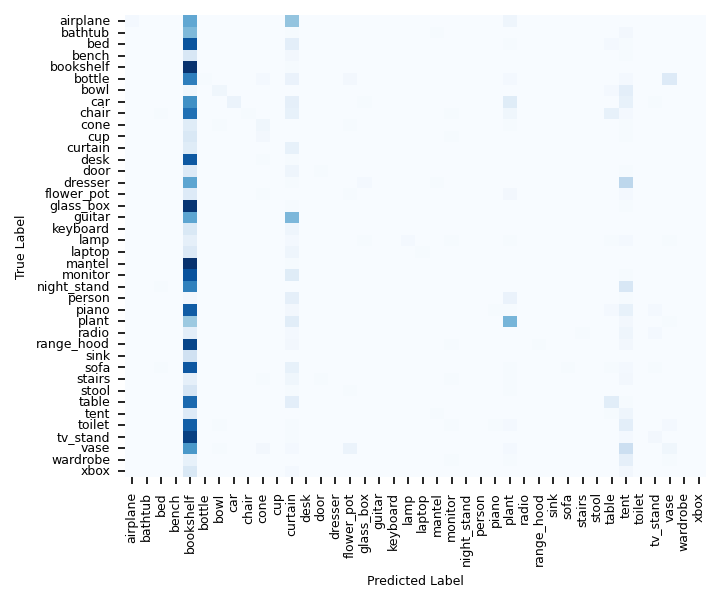

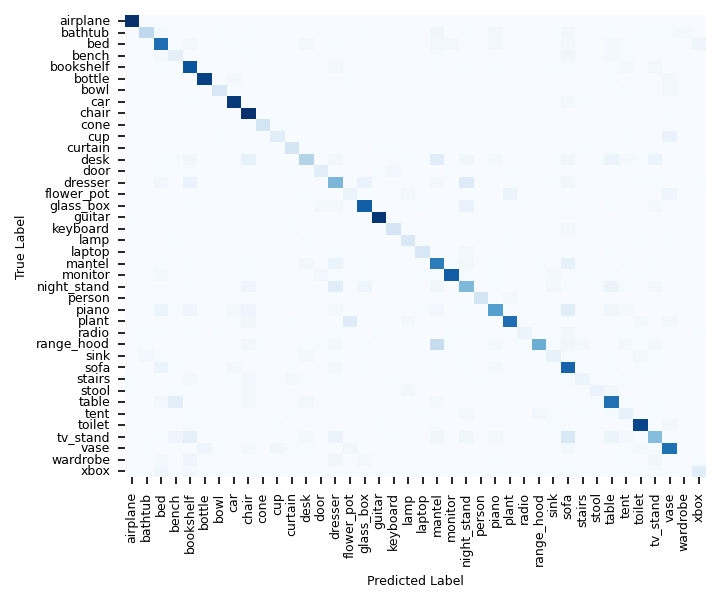

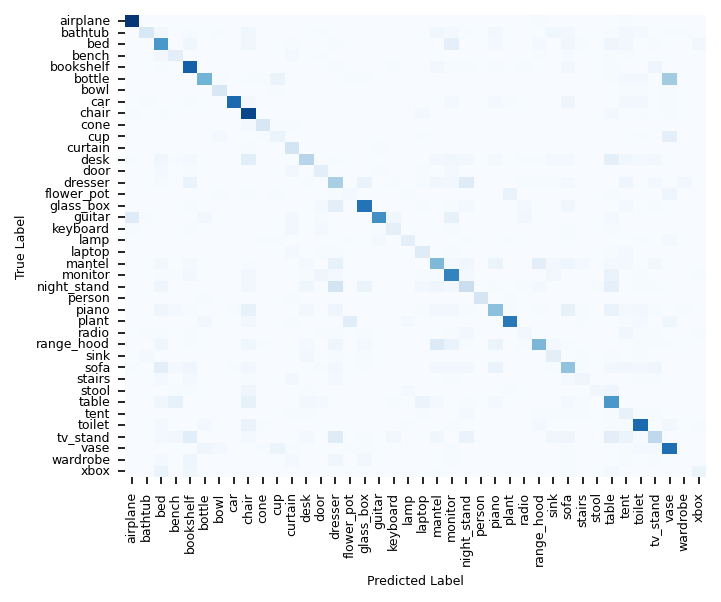

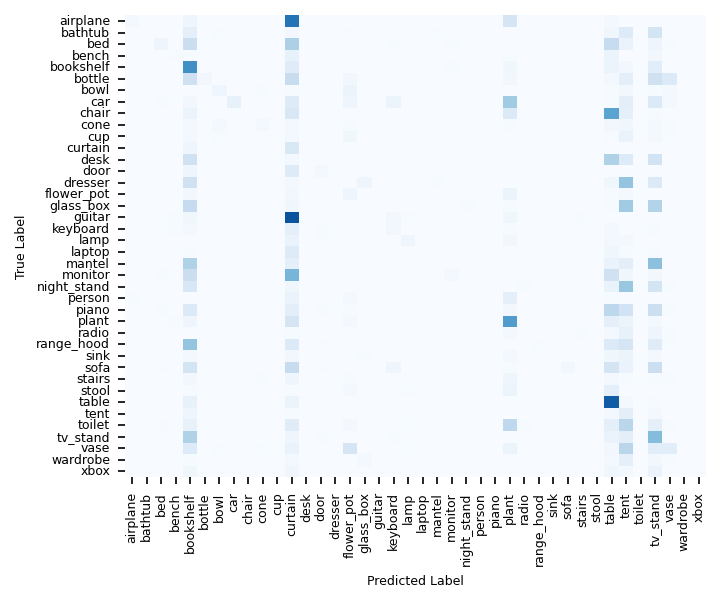

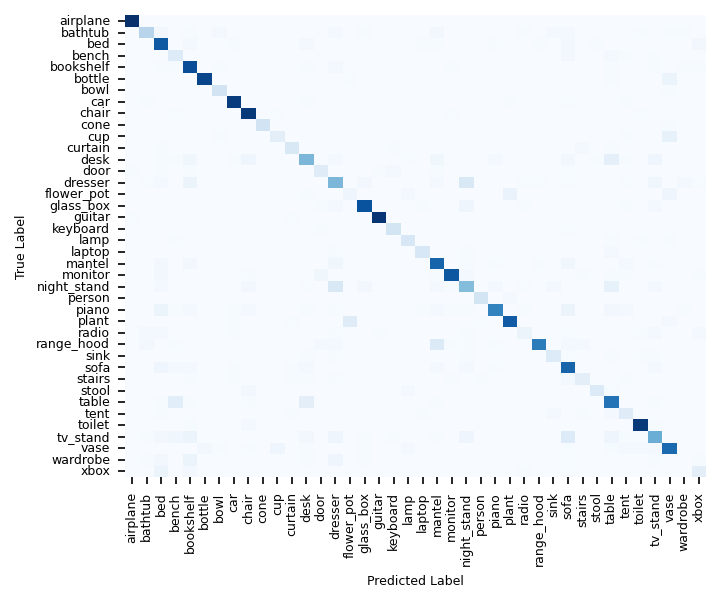

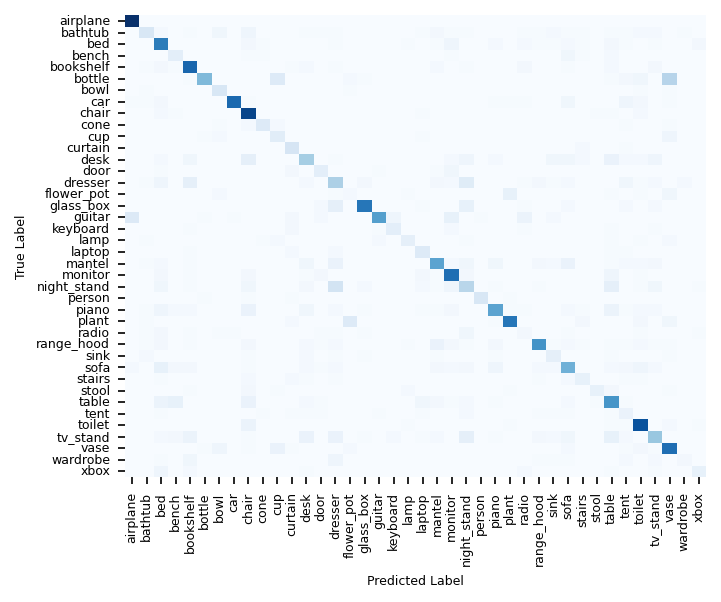

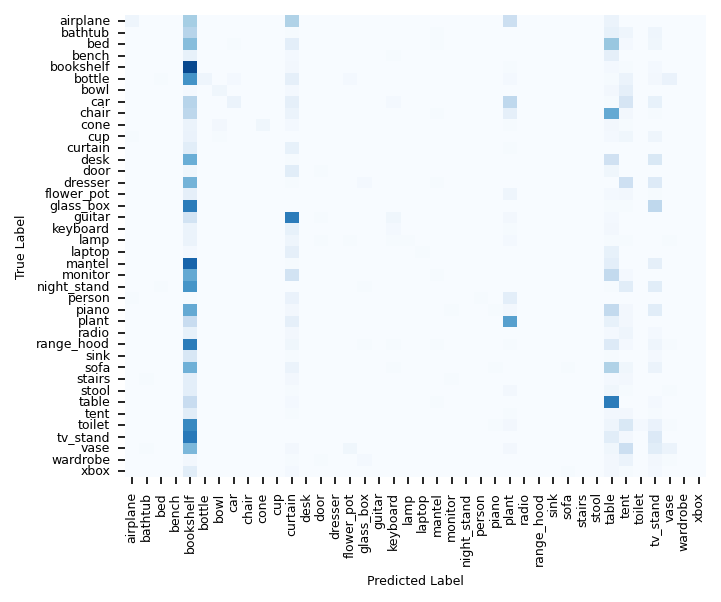

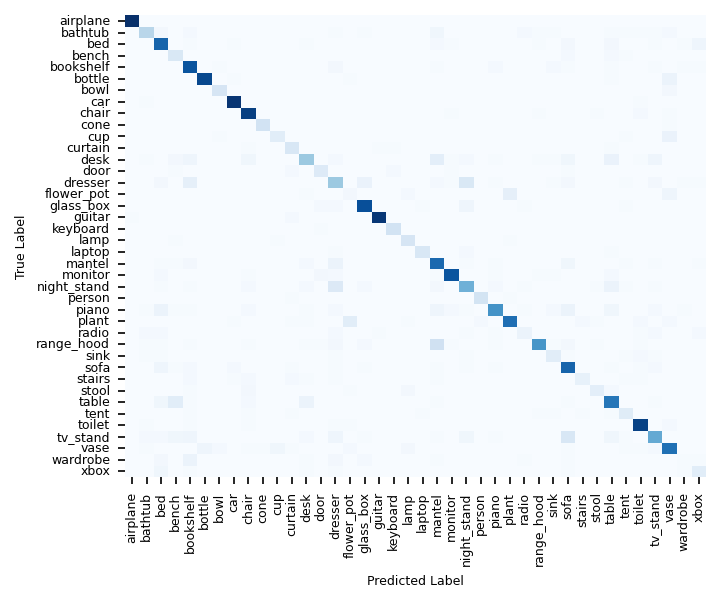

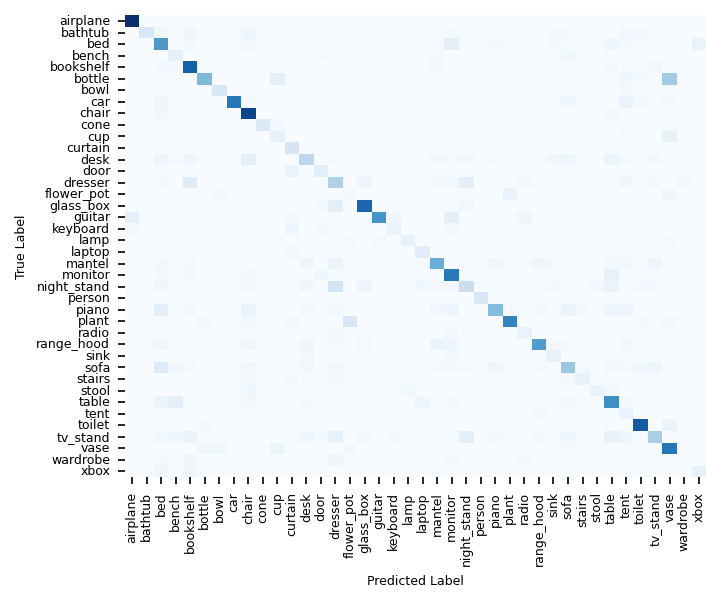

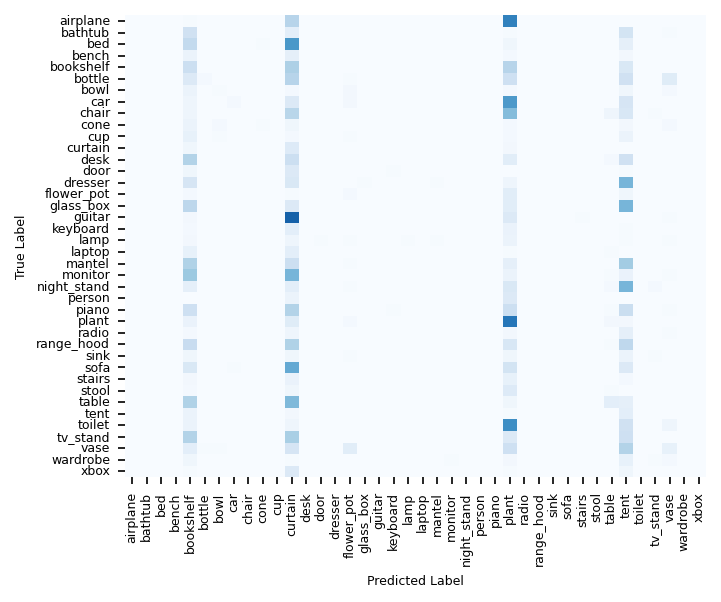

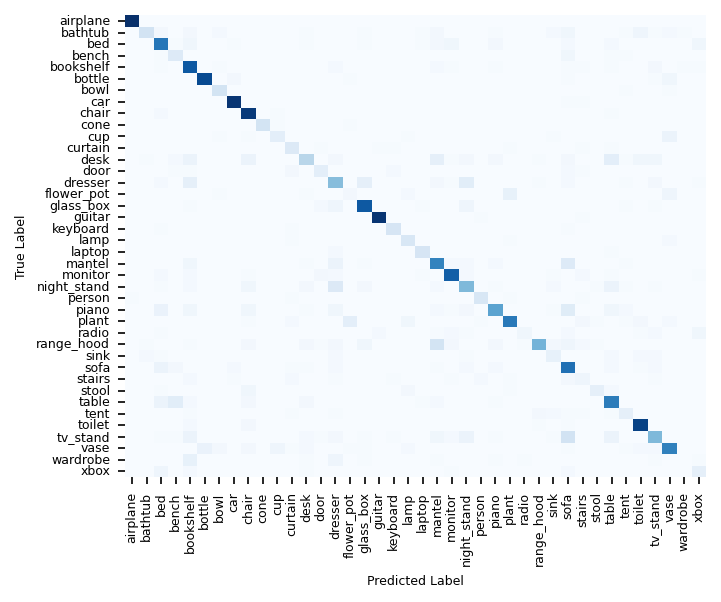

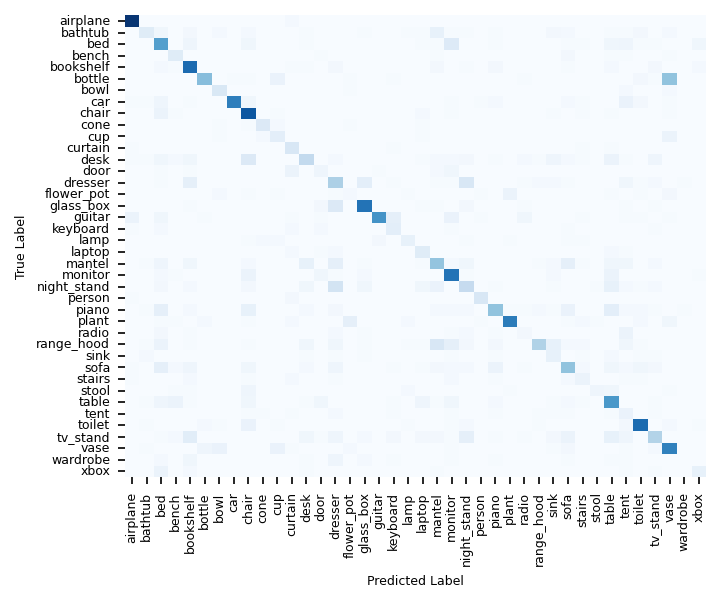

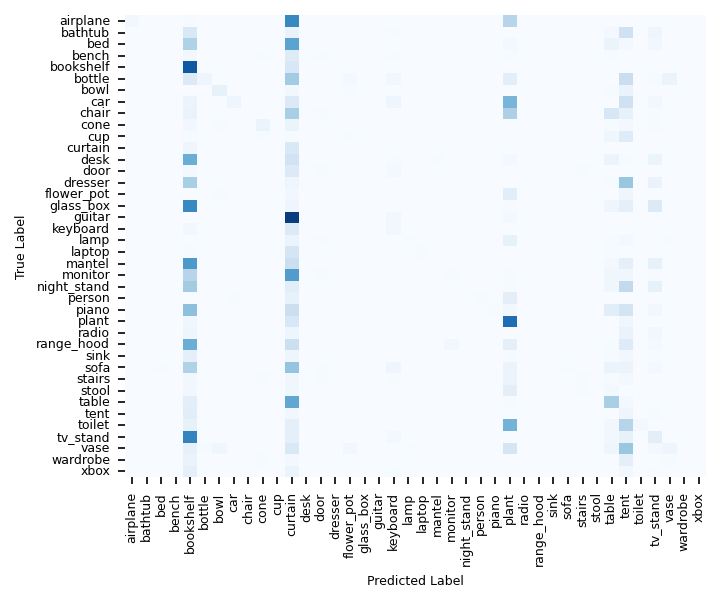

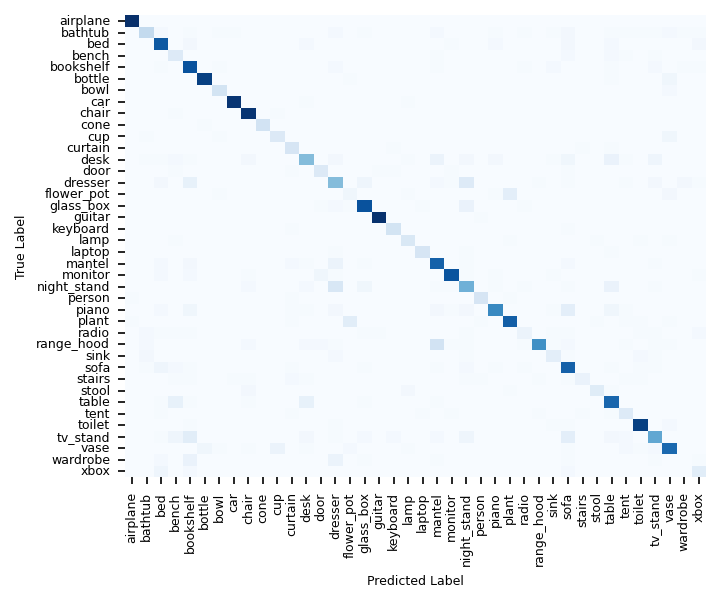

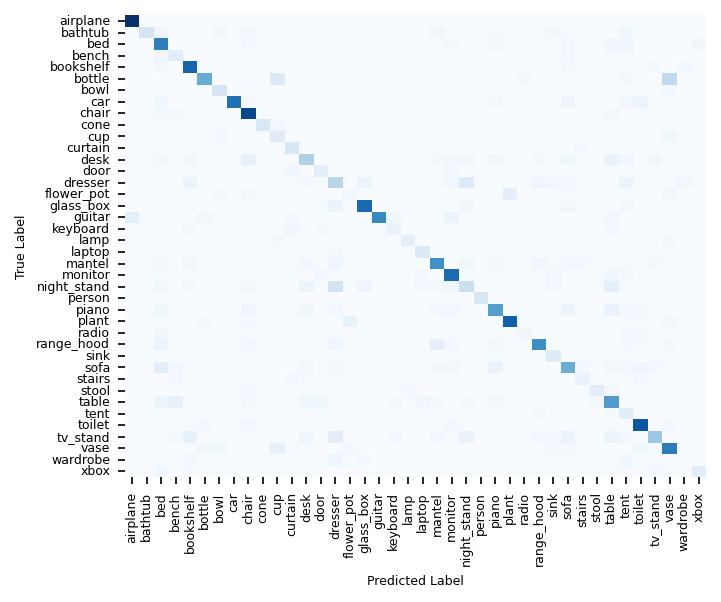

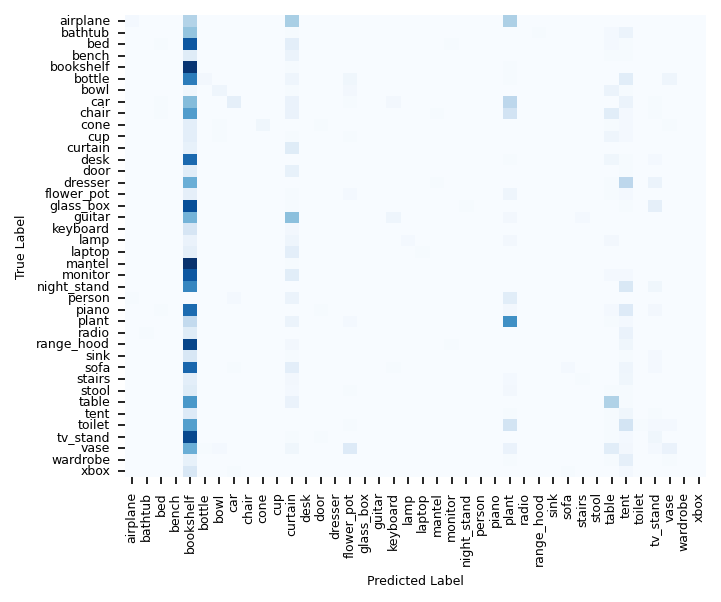

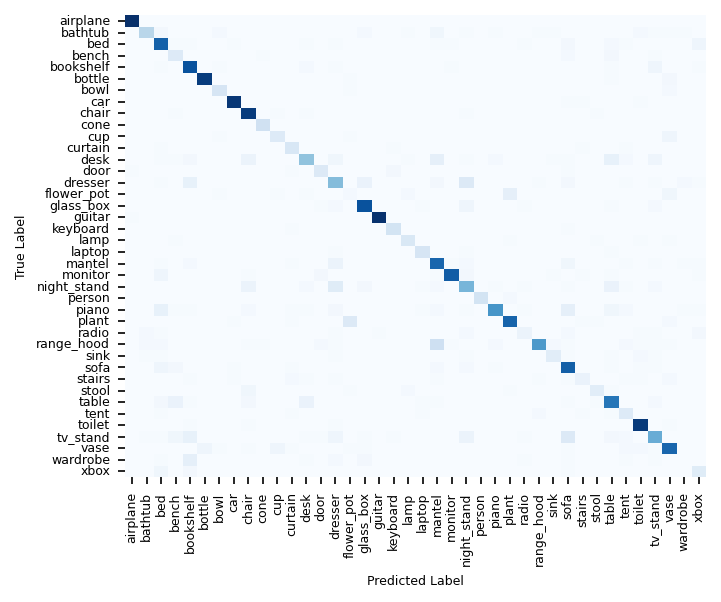

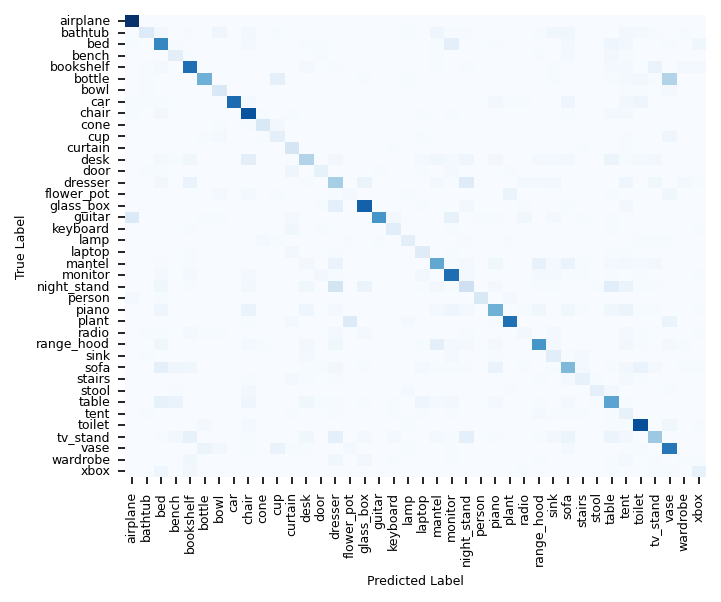

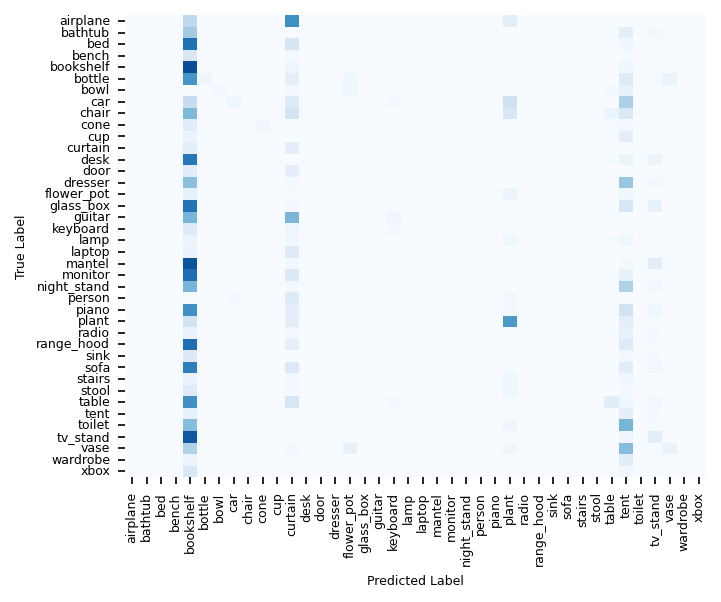

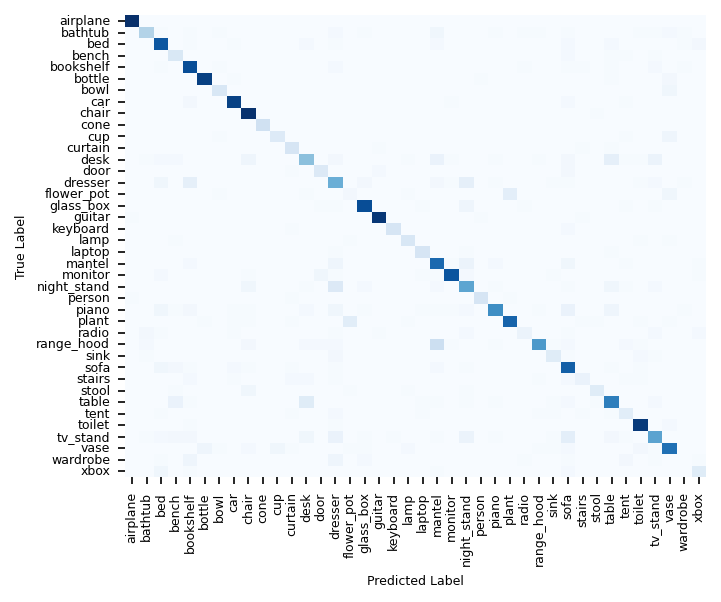

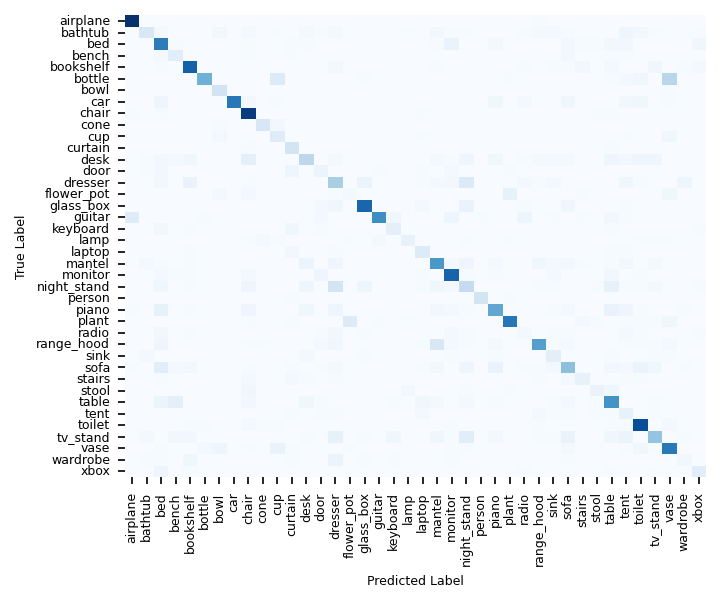

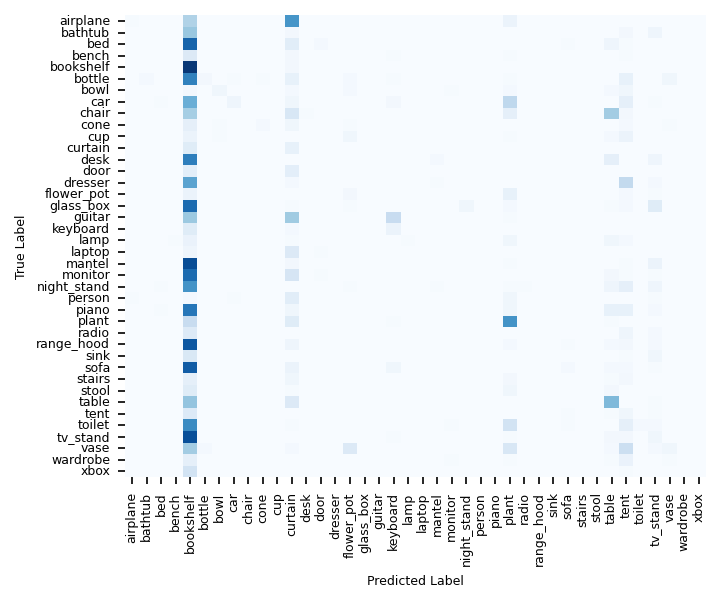

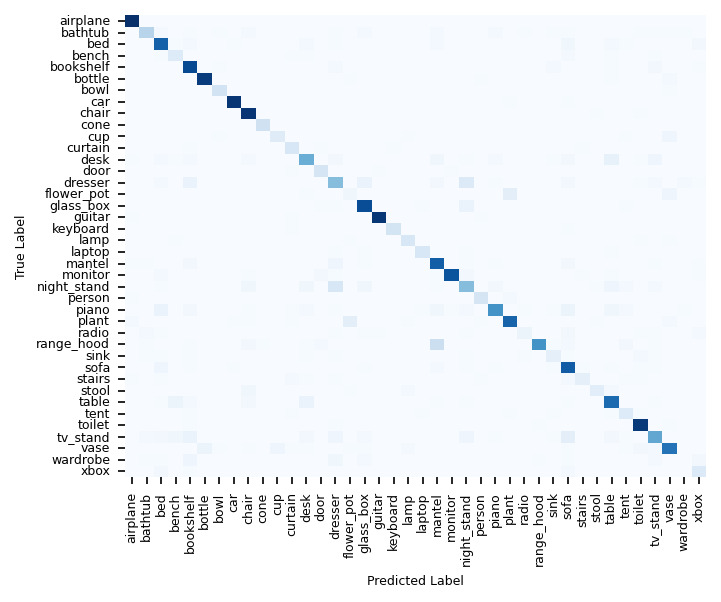

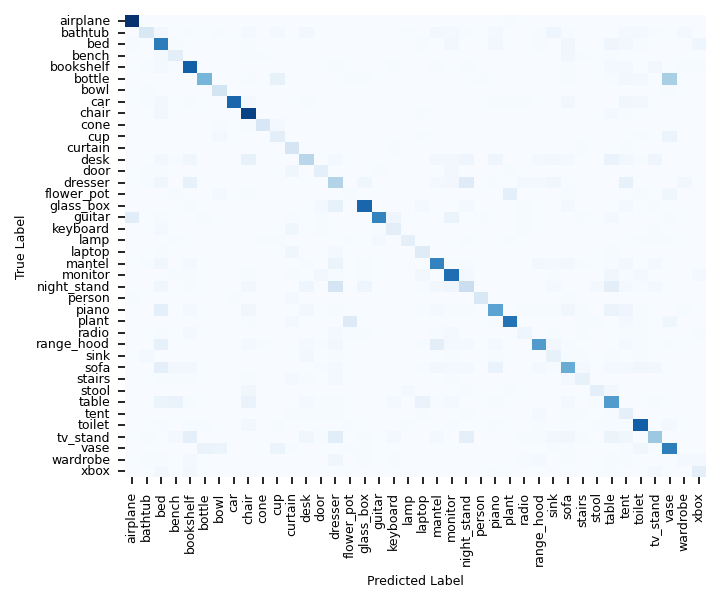

In [44]:
def make_confusion_matrix_small(cm, class_names):
    fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
    plt.rcParams.update({'font.size': 6})
    ax = sns.heatmap(
        data=cm,
        annot=False,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names.values(),
        yticklabels=class_names.values(),
        ax=ax,
        vmax=100,
        vmin=0,
        cbar=False
      )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    return fig, ax

# Create confusion matrices for all combinations of models and test sets
for model in results:
  for test_set in results[model]:
    fig, ax = make_confusion_matrix_small(results[model][test_set]["confusion_matrix"], class_names)
    ax.set_title('')
    fig.savefig(os.path.join(cm_savepath, f'cm_{model}_{test_set}.png'), bbox_inches='tight')